In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMWB_Train/MWB_TRAIN.csv"
path_test  = "dfFinalMWB_Test/MWB_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 1157 filas, 30 columnas
Dimensiones de Test:  321 filas, 30 columnas

--- Tipos de datos en Train ---
User_ID                          object
Age                               int64
Gender                           object
Occupation                       object
Relationship_Status              object
Primary_Platform                 object
Daily_Usage_Hours               float64
Platforms_Used_Count              int64
Posts_Per_Week                    int64
Late_Night_Usage                   bool
First_Check_Morning              object
Notifications_Per_Day             int64
FOMO_Score                      float64
Social_Comparison_Score         float64
Validation_Seeking_Score        float64
Scroll_Without_Purpose          float64
Tried_To_Cut_Back                  bool
Failed_To_Cut_Back                 bool
Anxiety_Score                   float64
Depression_Score                float64
Loneliness_Score             

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,MALE,WORKING PROFESSIONAL,IN A RELATIONSHIP,YOUTUBE,2.9,4,3,False,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,LOW
1,USR00002,19,MALE,STUDENT,MARRIED,INSTAGRAM,4.8,1,0,True,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,SEVERE
2,USR00003,40,MALE,STUDENT,IN A RELATIONSHIP,YOUTUBE,4.4,4,5,False,...,5.6,5.3,6.3,6.6,5.8,2.8,0.0,1.5,5.6,HIGH
3,USR00007,38,FEMALE,STUDENT,IN A RELATIONSHIP,FACEBOOK,5.0,4,4,True,...,7.2,0.5,4.8,8.2,6.8,5.4,3.2,3.7,5.5,HIGH
4,USR00008,22,FEMALE,UNEMPLOYED,SINGLE,TWITTER/X,3.4,5,2,False,...,3.1,2.9,3.8,10.0,6.8,6.7,2.9,6.6,6.2,MODERATE


In [3]:
# 1. Definir la variable objetivo
le = LabelEncoder()
df_train['Addiction_Level'] = le.fit_transform(df_train['Addiction_Level'])
df_test['Addiction_Level'] = le.transform(df_test['Addiction_Level'])
target_col = "Addiction_Level"

columnas_a_dropear = [
    "User_ID",                 
    "Mental_Wellbeing_Score",         
    "Anxiety_Score",           
    "Depression_Score",       
    "Loneliness_Score",        
    "Self_Esteem_Score",       
    "FOMO_Score",              
    "Social_Comparison_Score", 
    "Validation_Seeking_Score",
    "Productivity_Loss_Score",
    "Sleep_Quality_Score"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (1157, 18)
Dimensiones de y_train (Objetivo):    (1157,)
Dimensiones de X_test (Predictoras):  (321, 18)
Dimensiones de y_test (Objetivo):     (321,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform', 'Daily_Usage_Hours', 'Platforms_Used_Count', 'Posts_Per_Week', 'Late_Night_Usage', 'First_Check_Morning', 'Notifications_Per_Day', 'Scroll_Without_Purpose', 'Tried_To_Cut_Back', 'Failed_To_Cut_Back', 'Sleep_Hours', 'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week', 'Screen_Free_Time_Hrs']


In [4]:
# 1. Identificar cuáles son las columnas numéricas
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. Ajustar  y transformar
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Usage_Hours', 'Platforms_Used_Count', 'Posts_Per_Week', 'Notifications_Per_Day', 'Scroll_Without_Purpose', 'Sleep_Hours', 'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week', 'Screen_Free_Time_Hrs']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                            -0.0
Daily_Usage_Hours               0.0
Platforms_Used_Count            0.0
Posts_Per_Week                 -0.0
Notifications_Per_Day          -0.0
Scroll_Without_Purpose          0.0
Sleep_Hours                    -0.0
Offline_Relationship_Quality    0.0
Physical_Activity_Hrs_Week      0.0
Screen_Free_Time_Hrs           -0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                             1.0
Daily_Usage_Hours               1.0
Platforms_Used_Count            1.0
Posts_Per_Week                  1.0
Notifications_Per_Day           1.0
Scroll_Without_Purpose          1.0
Sleep_Ho

,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,First_Check_Morning,Notifications_Per_Day,Scroll_Without_Purpose,Tried_To_Cut_Back,Failed_To_Cut_Back,Sleep_Hours,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs
0,0.067334,MALE,WORKING PROFESSIONAL,IN A RELATIONSHIP,YOUTUBE,-0.789127,0.456438,-0.491000,False,WITHIN 5 MIN,0.058735,2.189671,False,False,-0.899325,-0.832606,1.667503,0.072920
1,-1.221326,MALE,STUDENT,MARRIED,INSTAGRAM,0.132625,-1.343900,-2.132871,True,WITHIN 5 MIN,1.544618,1.711265,True,True,-0.753349,-1.821444,-1.272773,0.196357
2,1.238843,MALE,STUDENT,IN A RELATIONSHIP,YOUTUBE,-0.061428,0.456438,0.603580,False,WITHIN 5 MIN,1.878184,0.323886,False,True,0.049521,-1.327025,-1.812824,-0.914570
3,1.004541,FEMALE,STUDENT,IN A RELATIONSHIP,FACEBOOK,0.229652,0.456438,0.056290,True,WITHIN 5 MIN,-1.093583,-1.350537,False,True,1.217331,-0.041536,0.107357,0.443229
4,-0.869873,FEMALE,UNEMPLOYED,SINGLE,TWITTER/X,-0.546561,1.056551,-1.038291,False,WITHIN 5 MIN,0.119383,-0.680768,True,False,2.531118,0.601208,-0.072660,2.233056


In [5]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform','First_Check_Morning']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test (Crucial)
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 31


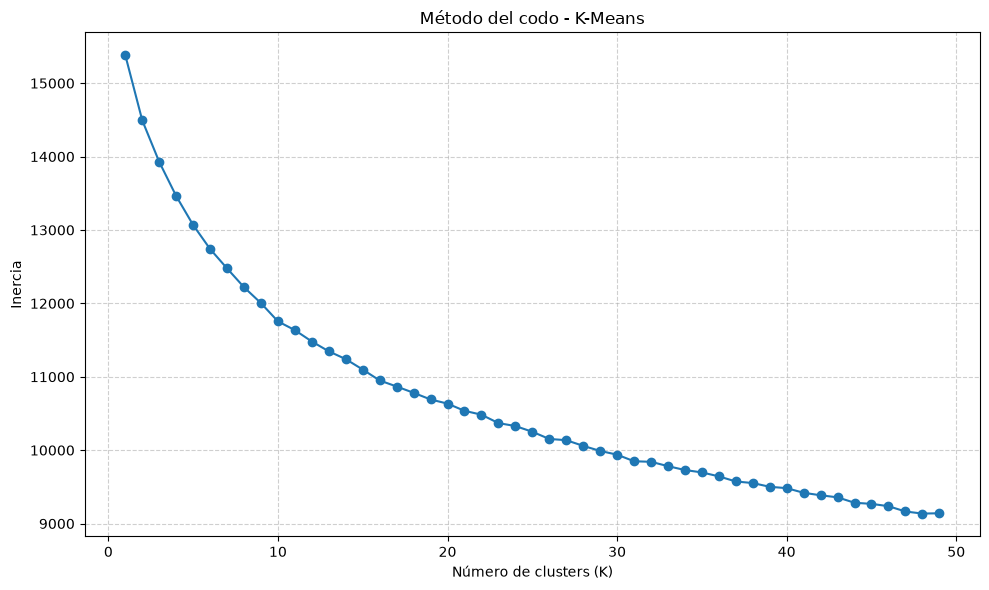

In [10]:
# ==========================================
# 5. BUSCAR EL NÚMERO ÓPTIMO DE CLUSTERS
#    MÉTODO DEL CODO
# ==========================================

inertias = []

K = range(1, 50)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=46,
        n_init=10
    )

    kmeans.fit(X_train_codificado)

    inertias.append(kmeans.inertia_)
# ==========================================
# GRÁFICO DEL CODO
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    K,
    inertias,
    marker='o'
)

plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del codo - K-Means')

plt.grid(
    True,
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()
plt.show()

In [28]:
# ==========================================
# 6. CREAR EL MODELO K-MEANS
# ==========================================

K_OPTIMO = 5

kmeans = KMeans(
    n_clusters=K_OPTIMO,
    random_state=46,
    n_init=10
)

clusters = kmeans.fit_predict(X_train_codificado)


# Añadir cluster al dataset
df_cluster = df_train.copy()

df_cluster['Cluster'] = clusters


# ==========================================
# 7. TAMAÑO DE CADA PERSONA
# ==========================================

print("==============================================")
print("           TAMAÑO DE LOS CLUSTERS")
print("==============================================")

print(
    df_cluster['Cluster']
    .value_counts()
    .sort_index()
)

           TAMAÑO DE LOS CLUSTERS
Cluster
0    211
1    224
2    265
3    241
4    216
Name: count, dtype: int64


In [29]:
# ==========================================
# 8. PERFIL DE CADA BEHAVIORAL PERSONA
# ==========================================

perfil_numerico = df_cluster.groupby(
    'Cluster'
)[columnas_numericas].mean()

display(
    perfil_numerico.round(2)
)

,Age,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Notifications_Per_Day,Scroll_Without_Purpose,Sleep_Hours,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs
Cluster,,,,,,,,,,
0,31.94,4.85,5.47,4.21,53.76,5.46,7.32,5.36,3.32,2.36
1,26.50,4.14,3.23,3.79,78.22,3.90,6.21,7.45,2.52,2.73
2,35.22,4.13,2.63,3.48,38.26,5.08,5.96,4.88,2.41,3.05
3,23.04,4.47,2.68,4.07,44.67,6.10,6.97,5.57,3.89,4.07
4,30.01,5.17,2.44,4.02,91.31,6.62,6.32,4.20,3.03,2.55


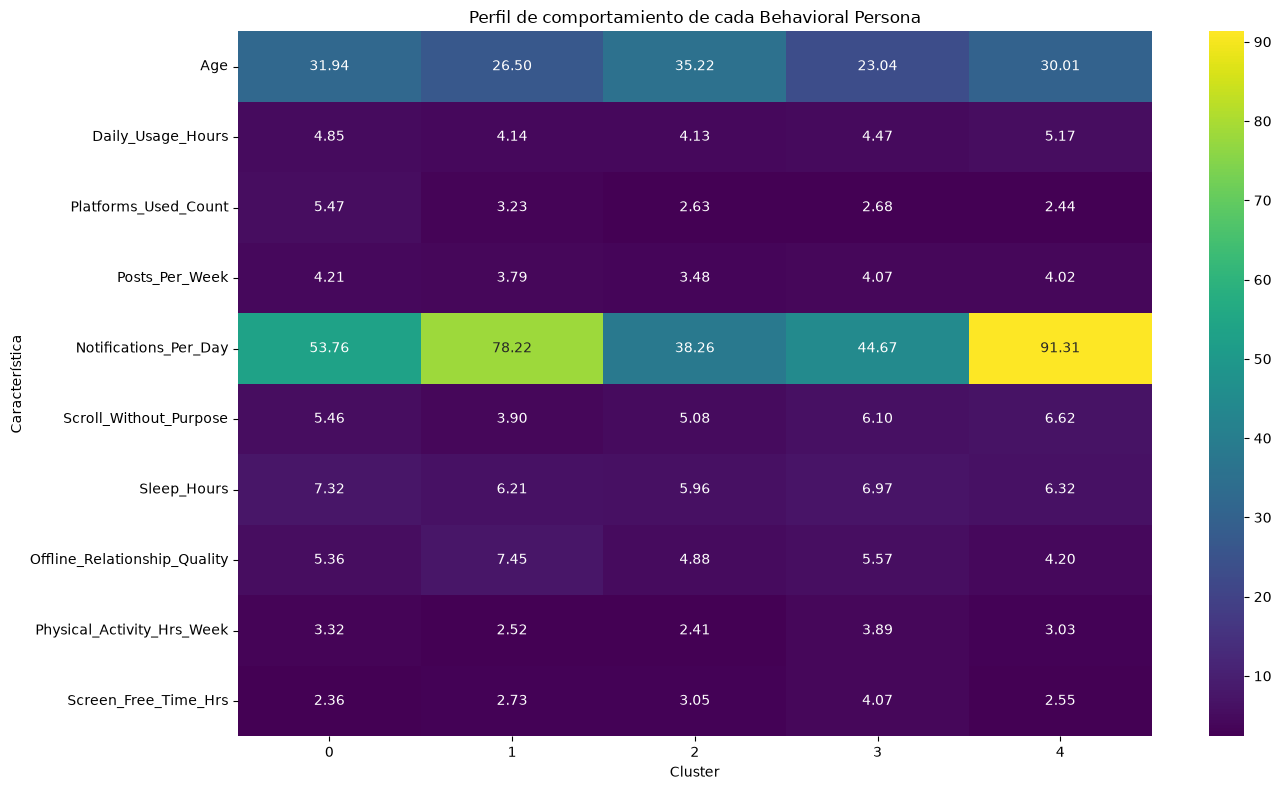

In [30]:
# ==========================================
# 9. HEATMAP DE LAS PERSONAS
# ==========================================

plt.figure(figsize=(14, 8))

sns.heatmap(
    perfil_numerico.T,
    annot=True,
    fmt='.2f',
    cmap='viridis'
)

plt.title(
    'Perfil de comportamiento de cada Behavioral Persona'
)

plt.xlabel('Cluster')
plt.ylabel('Característica')

plt.tight_layout()
plt.show()

1. Cluster 4 — "El Usuario en Riesgo / Compulsivo"

Patrón: Registra las cifras más elevadas de consumo: mayor uso diario (5.17 h), máximo nivel de scroll sin propósito (6.62) y bombardeo de notificaciones (91.31).

Impacto: Reporta la peor calidad en sus relaciones offline (4.20), lo que lo convierte en el perfil objetivo para entrenar el predictor de riesgo de adicción.

2. Cluster 0 — "El Multi-Plataforma / Omnívoro Digital"

Patrón: Se distingue radicalmente por usar el doble de plataformas que los demás (5.47 redes frente al promedio general de 2.5–3.2).

Impacto: A pesar de su dispersión en múltiples apps, mantiene un uso diario moderado (4.85 h) y el mejor nivel de descanso (7.32 h de sueño).

3. Cluster 1 — "El Conectado Social Intencional"

Patrón: Recibe muchas notificaciones (78.22), pero registra el menor tiempo de scroll pasivo (3.90).

Impacto: Utiliza las redes de forma activa y funcional, logrando la mayor calidad de relaciones en el mundo real (7.45).

4. Cluster 3 — "El Joven Activo / Equilibrado"

Patrón: Es el grupo más joven (23 años) y compensa su consumo digital con hábitos saludables.

Impacto: Lidera en actividad física semanal (3.89 h) y en tiempo libre de pantallas (4.07 h).

5. Cluster 2 — "El Pasivo / Desconectado"

Patrón: Es el grupo de mayor edad (35 años) y con menor interacción en redes: mínimas notificaciones (38.26) y menor frecuencia de publicación (3.48/semana).

Impacto: Muestra un déficit en el descanso (5.96 h de sueño) y poca actividad física, aunque no derivado del uso de redes.

In [31]:
distribucion_phq = pd.crosstab(
    df_cluster['Cluster'],
    df_cluster['Addiction_Level'],
    normalize='index'
) * 100

print("==============================================")
print("       DISTRIBUCIÓN PHQ-9 POR CLUSTER")
print("==============================================")

display(
    distribucion_phq.round(2)
)

       DISTRIBUCIÓN PHQ-9 POR CLUSTER


Addiction_Level,0,1,2,3
Cluster,,,,
0,26.54,21.80,25.59,26.07
1,19.64,37.50,30.80,12.05
2,23.02,36.60,27.17,13.21
3,24.48,31.95,31.54,12.03
4,31.48,11.57,27.31,29.63


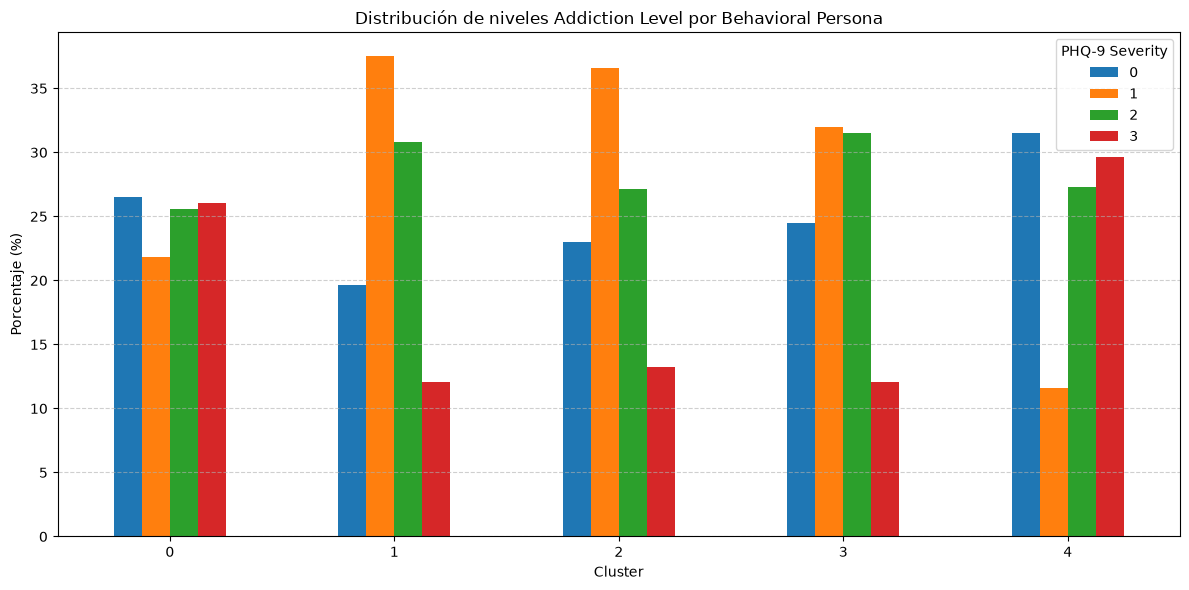

In [32]:
distribucion_phq.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title(
    'Distribución de niveles Addiction Level por Behavioral Persona'
)

plt.xlabel('Cluster')
plt.ylabel('Porcentaje (%)')

plt.xticks(rotation=0)
plt.legend(title='PHQ-9 Severity')

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()
plt.show()